<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/supervised/level-1_and_meta-classifier_with_k-fold_spliter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import scipy.io as sci
import numpy as np
import matplotlib.pyplot as plt
import keras
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Supervised/level1-classifier/dataset.mat"

In [ ]:
dataset = sci.loadmat(dataset_path)

In [ ]:
data_tr = dataset['data_tr']
data_te= dataset['data_te']
labels_tr = dataset['labels_tr'].flatten()
labels_te = dataset['labels_te'].flatten()

In [ ]:
data_tr.shape, labels_tr.shape, data_te.shape, labels_te.shape

((600, 2), (600,), (600, 2), (600,))

In [ ]:
# Check if the dataset is not distributed properly
print(np.bincount(labels_tr))
print(np.bincount(labels_te))

[  0 300 300]
[  0 300 300]


Class 0 0%

Class 1 50%

Class 2 50%

**Perfectly balanced**

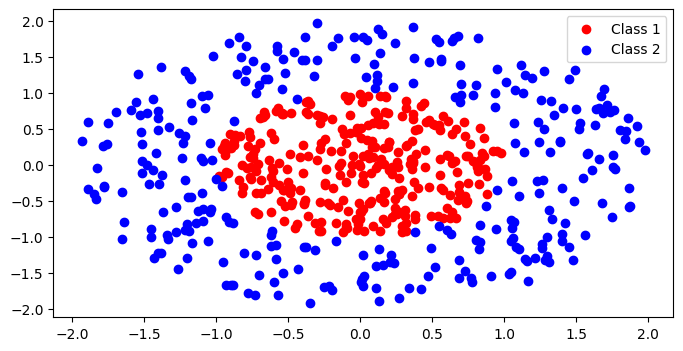

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(data_tr[labels_tr ==1, 0], data_tr[labels_tr == 1,1], c='r', label="Class 1")
plt.scatter(data_tr[labels_tr ==2, 0], data_tr[labels_tr == 2,1], c='b', label="Class 2")
plt.legend()


In [ ]:
# TBD: stratified sampling of the training set for training level-1 classifiers and meta-classifier
# (you can use external function to do it)
# create a k-fold spliter
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
# split only trainning dataset for taining level-1 & meta-classifier
folds =[]
for train_index, test_index in skf.split(data_tr, labels_tr):
  folds.append((train_index, test_index))
train_idx_f1, test_idx_f1 = folds[0]
train_idx_f2, test_idx_f2 = folds[1]
# obtain:
data_f1 = data_tr[test_idx_f1]
labels_f1 = labels_tr[test_idx_f1]
data_f2 = data_tr[test_idx_f2]
labels_f2 = labels_tr[test_idx_f2]

In [ ]:
# train level-1 classifiers on fold1
models = []
# SVM with Gaussion kernal
models.append(SVC(kernel='rbf', gamma=0.2, probability=True).fit(data_f1, labels_f1))

# SVM with Polynomial kernal
models.append(SVC(kernel='poly', degree=3, probability=True).fit(data_f1, labels_f1))

# Decision Tree
models.append(DecisionTreeClassifier(criterion='gini', max_depth=20).fit(data_f1, labels_f1))

# Random forest
models.append(RandomForestClassifier(n_estimators=50).fit(data_f1, labels_f1))



In [ ]:
models

[SVC(gamma=0.2, probability=True),
 SVC(kernel='poly', probability=True),
 DecisionTreeClassifier(max_depth=20),
 RandomForestClassifier(n_estimators=50)]

In [ ]:
# Make predictions on fold2 (to be later used to train the meta-clasifier )
N = len(models)
Predictions = np.zeros(shape = (len(data_f2), N)) # the predicted class
Scores = np.zeros(shape = (len(data_f2), N)) # the scores associated to the predictions

for i, model in enumerate(models):
  Predictions[:, i] = model.predict(data_f2)
  Scores[:, i] = model.predict_proba(data_f2)[:, 1] # <-- prob. of being a specific


In [ ]:
# Train the stacked classifier on fold2 using AdaBoost
meta_classifier = AdaBoostClassifier(n_estimators=50).fit(Scores, labels_f2)

### Your assignment
Next friday 21/03

In [ ]:
# TBD1: Compute performance on test set for level-1 classifers and meta-clasifier
print("Performance of level-1 calssifiers\n")
for i, model in enumerate(models):
  y_pred = model.predict(data_te)
  acc = accuracy_score(labels_te, y_pred)
  print(f'{i+1} model: {model} \t accuracy: {acc:.4f}')

# create an input for meta-clasifier
meta_test = np.column_stack([
    model.predict_proba(data_te)[:, 1] for model in models
])
print("\nPerformance of meta-classifier")
meta_pred = meta_classifier.predict(meta_test)
meta_acc = accuracy_score(labels_te, meta_pred)
print(f'model: meta-classifier \t accuracy: {meta_acc:.4f}')

Performance of level-1 calssifiers

1 model: SVC(gamma=0.2, probability=True) 	 accuracy: 0.9550
2 model: SVC(kernel='poly', probability=True) 	 accuracy: 0.6517
3 model: DecisionTreeClassifier(max_depth=20) 	 accuracy: 0.9650
4 model: RandomForestClassifier(n_estimators=50) 	 accuracy: 0.9733

Performance of meta-classifier
model: meta-classifier 	 accuracy: 0.9950


In [ ]:
# TBD2: what happens to the performance if instead of "Scores" we use "Predictions"?
meta_classifier_with_pred = AdaBoostClassifier(n_estimators=50).fit(Predictions, labels_f2)
# Let's compute the performance on using Predictions
print("Peformanc of meta-classifier with predictions")
meta_test_with_pred = np.column_stack([
    model.predict_proba(data_te)[:, 1] for model in models
])
meta_pred_with_pred = meta_classifier_with_pred.predict(meta_test_with_pred)
meta_acc_with_pred = accuracy_score(labels_te, meta_pred_with_pred)
print(f'Accuracy: {meta_acc_with_pred:.4f}')

Peformanc of meta-classifier with predictions
Accuracy: 0.5000


**It seems the accuracy drop when we use `Predictions` instead of `Scores` by almost *50%***

In [ ]:
models

[SVC(gamma=0.2, probability=True),
 SVC(kernel='poly', probability=True),
 DecisionTreeClassifier(max_depth=20),
 RandomForestClassifier(n_estimators=50)]

In [ ]:
# TBD3: what happens to the performance if we do not split the training set and we use it for training the level-1
# classidfier, compute the prodictions, and train the meta-classifier?
models_2 = []
models_2.append(SVC(kernel='rbf', gamma=0.2, probability=True).fit(data_tr, labels_tr)) # SVM with Gaussian kernal
models_2.append(SVC(kernel='poly', probability=True).fit(data_tr, labels_tr)) # SVM with polynomial kernel
models_2.append(DecisionTreeClassifier(max_depth=20).fit(data_tr, labels_tr)) # Decision Tree classifier
models_2.append(RandomForestClassifier(n_estimators=50).fit(data_tr, labels_tr)) # Random Forest classifier

# Get the prediction score on data_tr
Scores_2 = np.column_stack([
    model.predict_proba(data_tr)[:, 1] for model in models_2
])

print("Performance of level-1 calssifiers\n")
for i, model in enumerate(models_2):
  y_pred = model.predict(data_te)
  acc = accuracy_score(labels_te, y_pred)
  print(f'{i+1} model: {model} \t testing accuracy: {acc:.4f}')

# Train the stack classifier on Scores of level-1 classifier using AdaBoost
meta_classifier_2 = AdaBoostClassifier(n_estimators=50).fit(Scores_2, labels_tr)

# create an input for meta-clasifier
meta_test_2 = np.column_stack([
    model.predict_proba(data_te)[:, 1] for model in models_2
])
print("\nPerformance of meta-classifier")
meta_pred_2 = meta_classifier_2.predict(meta_test_2)
meta_acc_2 = accuracy_score(labels_te, meta_pred_2)
print(f'model: meta-classifier \t testing accuracy: {meta_acc_2:.4f}')

train_meta_pred = meta_classifier_2.predict(Scores_2)
print(f'model: meta-classifier \t training accuracy: {accuracy_score(labels_tr, train_meta_pred):.4f}')


Performance of level-1 calssifiers

1 model: SVC(gamma=0.2, probability=True) 	 testing accuracy: 0.9700
2 model: SVC(kernel='poly', probability=True) 	 testing accuracy: 0.6100
3 model: DecisionTreeClassifier(max_depth=20) 	 testing accuracy: 0.9650
4 model: RandomForestClassifier(n_estimators=50) 	 testing accuracy: 0.9667

Performance of meta-classifier
model: meta-classifier 	 testing accuracy: 0.9650
model: meta-classifier 	 training accuracy: 1.0000


**As it shows in the result since I did not split my dataset this time to fold it seem the meta-classifier `Overfitting`**